### There are several ways to establish connection to local postgresql db but we will use pandas and sqlalchemy libraries

### To install it RUN THE NEXT CELL BY CLICKING ON IT AND SHIFT+ENTER or click RUN BUTTON ABOVE

In [17]:
!pip install pandas sqlalchemy
!pip install psycopg2-binary

### As now we have proper libraries we can import and use them 

### Execute the following cell 

In [11]:
import pandas as pd
from sqlalchemy import create_engine

def connect_to_db(dbname: str, user: str, password: str, host: str = "localhost", port: str = "5432"):
    try:
        conn_str = f"postgresql://{user}:{password}@{host}:{port}/{dbname}"
        engine = create_engine(conn_str)
        print(f"Engine created for database: {dbname}")
        return engine
    except Exception as e:
        print(f"Error creating engine for {dbname}: {e}")
        return None


### in previous cell we creted connect_to_db function which we can reuse to connect to both of our DBs, we just need to provide propper attributers. 

### In the next cell you can find example of establishing connection to SRC DB and reading data from s1.s1_channels into separate pandas dataframe

### Execute the following cell 

In [13]:
src_engine = connect_to_db(
    dbname="dwh_src_hw_db",
    user="postgres",
    password="postgres"
)

s1_channels_df = pd.read_sql("SELECT * FROM s1.s1_channels", src_engine)
s1_channels_df

Engine created for database: dwh_src_hw_db


,channel_id,channel_name,channel_location
0,1,STORE - 1,621 Hovde Circle
1,2,STORE - 2,9459 Trailsway Terrace
2,3,STORE - 3,23 Transport Street
3,4,STORE - 4,7 Pond Place
4,5,STORE - 5,6799 Armistice Avenue
...,...,...,...
153,154,YAOBAO.COM,Internet
154,155,CATALOG.ONLINER.BY,Internet
155,156,5ELEMENT.BY,Internet
156,157,ALLEGRO.PL,Internet


 ## YOUR TASK IS TO ESTABLISH SEPARATE 

 trg_engine 

 ## and conect to dwh_hw_db in the next cell

In [15]:
trg_engine = connect_to_db(
    dbname="dwh_hw_db",
    user="postgres",
    password="postgres"
)

lnd_s1_channels_df = pd.read_sql("SELECT * FROM lnd.lnd_s1_channels", trg_engine)
lnd_s1_channels_df

Engine created for database: dwh_hw_db


,channel_id,channel_name,channellocation
0,1,STORE - 1,621 Hovde Circle
1,2,STORE - 2,9459 Trailsway Terrace
2,3,STORE - 3,23 Transport Street
3,4,STORE - 4,7 Pond Place
4,5,STORE - 5,6799 Armistice Avenue
...,...,...,...
151,152,EBAY.COM,N/A - Internet
152,153,ALIEXPRESS.COM,N/A - Internet
153,154,YAOBAO.COM,N/A - Internet
154,155,CATALOG-ONLINER.BY,N/A - Internet


#### AS we have 2 DFs with data from 2 tables we need to compare them. To do so we can create separate DF s1_channels_comparison_df

### Execute the following cell 

In [20]:
s1_channels_comparison_df = s1_channels_df.merge(
    lnd_s1_channels_df,
    on='channel_id',
    how='outer',
    suffixes=('_src', '_lnd'),
    indicator=True  
)
s1_channels_comparison_df

,channel_id,channel_name_src,channel_location,channel_name_lnd,channellocation,_merge
0,1,STORE - 1,621 Hovde Circle,STORE - 1,621 Hovde Circle,both
1,10,STORE - 10,6840 Pennsylvania Terrace,STORE - 10,6840 Pennsylvania Terrace,both
2,100,STORE - 100,72760 Helena Avenue,STORE - 100,72760 Helena Avenue,both
3,101,STORE - 101,40 Lyons Place,STORE - 101,40 Lyons Place,both
4,102,STORE - 102,04 Ludington Pass,STORE - 102,04 Ludington Pass,both
...,...,...,...,...,...,...
153,95,STORE - 95,6354 Lukken Circle,STORE - 95,6354 Lukken Circle,both
154,96,STORE - 96,1 Lighthouse Bay Way,STORE - 96,1 Lighthouse Bay Way,both
155,97,STORE - 97,03 Moland Parkway,STORE - 97,03 Moland Parkway,both
156,98,STORE - 98,24450 Kim Center,STORE - 98,24450 Kim Center,both


### Since we use indicator=True in the merge, pandas automatically provides the _merge column with values left_only, right_only, or both for the ID values.

### However, we want to make the statuses more meaningful, similar to what we did in SQL and also check for differences in other attributes, not just IDs.
### For this reason, I have prepared a separate function specifically for computing reconciliation_status for the channels table.

### Execute the following cell 

In [23]:
def get_s1_channels_reconciliation_status(row):
    if row['_merge'] == 'left_only':
        return 'Only in source'
    elif row['_merge'] == 'right_only':
        return 'Only in landing'
    
    mismatches = []
    if row['channel_name_src'] != row['channel_name_lnd']:
        mismatches.append('channel_name')
    if row['channel_location'] != row['channellocation']:
        mismatches.append('channel_location')
    
    if mismatches:
        return 'Mismatch in ' + ', '.join(mismatches)
    
    return 'Match'

### Since this function expects a single row as input, we can apply it to our s1_channel_comparison_df and create a new column to store the adapted reconciliation statuses.

### Execute the following cell 


In [26]:
s1_channels_comparison_df['reconciliation_status'] = s1_channels_comparison_df.apply(get_s1_channels_reconciliation_status, axis=1)

### And now, let’s keep only the rows with discrepancies (i.e., excluding rows where everything matches).

In [31]:
s1_channels_issues_df = s1_channels_comparison_df[s1_channels_comparison_df['reconciliation_status'] != 'Match']
display(s1_channels_issues_df.head(20))

,channel_id,channel_name_src,channel_location,channel_name_lnd,channellocation,_merge,reconciliation_status
58,151,AMAZON.COM,Internet,AMAZON.COM,N/A - Internet,both,Mismatch in channel_location
59,152,EBAY.COM,Internet,EBAY.COM,N/A - Internet,both,Mismatch in channel_location
60,153,ALIEXPRESS.COM,Internet,ALIEXPRESS.COM,N/A - Internet,both,Mismatch in channel_location
61,154,YAOBAO.COM,Internet,YAOBAO.COM,N/A - Internet,both,Mismatch in channel_location
62,155,CATALOG.ONLINER.BY,Internet,CATALOG-ONLINER.BY,N/A - Internet,both,"Mismatch in channel_name, channel_location"
63,156,5ELEMENT.BY,Internet,5ELEMENT.BY,N/A - Internet,both,Mismatch in channel_location
64,157,ALLEGRO.PL,Internet,NaN,NaN,left_only,Only in source
65,158,AMAZON.COM,Internet,NaN,NaN,left_only,Only in source


# Task: Reconcile all other table pairs from SRC and LND, similar to what we did for the channels table.

## Instructions:

### Tables to compare:

###### s1.s1_products → lnd.lnd_s1_products
###### s1.s1_sales → lnd.lnd_s1_sales
###### s2.s2_channels → lnd.lnd_s2_channels
###### s2.s2_client_sales → lnd.lnd_s2_client_sales
###### s2.s2_clients → lnd.lnd_s2_clients
###### s2.s2_locations → lnd.lnd_s2_locations

## For each table pair:

### 1. Load the SRC and LND tables into pandas DataFrames.
### 2. Perform a full outer merge on the primary key column(s).
### 3. Apply a function like get_reconciliation_status(row) to classify each row into statuses:
###### 'Only in source'
###### 'Only in landing'
###### 'Mismatch in <column_name>'
###### 'Match'

### Keep only rows with issues (statuses != 'Match').

## 4. Create a consolidated result DataFrame with the following columns:

###### table_name	Name of the table being compared
###### key_column	Primary key column used for reconciliation
###### src_id	ID value from source table
###### trg_id	ID value from landing table
###### reconciliation_status	Status of the row (Only in source, Only in landing, etc.)

## 5. Populate the final result DataFrame with all discrepancies from all table comparisons.

### Tips / Methods:

### Use pd.merge(..., how='outer', indicator=True) to combine SRC and LND tables.
### Apply your reconciliation status function row-wise with df.apply(..., axis=1).
### Filter only rows with issues using df[df['reconciliation_status'] != 'Match'].
### Concatenate multiple issues_df DataFrames using pd.concat([...], ignore_index=True) to create the final consolidated DataFrame.

In [43]:
# Generic reconciliation function: builds a comparison dataframe for any table pair
def reconcile_tables(src_df, lnd_df, key_cols, compare_cols, table_name):
    merged = src_df.merge(
        lnd_df,
        on=key_cols,
        how='outer',
        suffixes=('_src', '_lnd'),
        indicator=True
    )

    def get_status(row):
        if row['_merge'] == 'left_only':
            return 'Only in source'
        elif row['_merge'] == 'right_only':
            return 'Only in landing'
        mismatches = []
        for col in compare_cols:
            src_col = col + '_src' if (col + '_src') in row.index else col
            lnd_col = col + '_lnd' if (col + '_lnd') in row.index else col
            if row[src_col] != row[lnd_col]:
                mismatches.append(col)
        if mismatches:
            return 'Mismatch in ' + ', '.join(mismatches)
        return 'Match'

    merged['reconciliation_status'] = merged.apply(get_status, axis=1)
    issues = merged[merged['reconciliation_status'] != 'Match'].copy()

    # build a single readable id string row-by-row safely for any keys
    src_key_cols = [col + '_src' if (col + '_src') in issues.columns else col for col in key_cols]
    
    if len(src_key_cols) == 1:
        issues['src_id'] = issues[src_key_cols[0]].astype(str)
    else:
        # explicitly join column values row by row using a list comprehension
        issues['src_id'] = [
            '|'.join(str(val) for val in row) 
            for row in issues[src_key_cols].values
        ]
    issues['trg_id'] = issues['src_id']

    result = pd.DataFrame({
        'table_name': table_name,
        'key_column': '+'.join(key_cols),
        'src_id': issues['src_id'],
        'trg_id': issues['trg_id'],
        'reconciliation_status': issues['reconciliation_status'].values
    })
    return result


# --- s1_channels ---
s1_channels_src = pd.read_sql("SELECT * FROM s1.s1_channels", src_engine)
s1_channels_lnd = pd.read_sql("SELECT * FROM lnd.lnd_s1_channels", trg_engine)
s1_channels_result = reconcile_tables(
    s1_channels_src, s1_channels_lnd,
    key_cols=['channel_id'],
    compare_cols=['channel_name', 'channel_location'],
    table_name='s1_channels'
)

# --- s1_products ---
s1_products_src = pd.read_sql("SELECT * FROM s1.s1_products", src_engine)
s1_products_lnd = pd.read_sql("SELECT * FROM lnd.lnd_s1_products", trg_engine)
s1_products_result = reconcile_tables(
    s1_products_src, s1_products_lnd,
    key_cols=['product_id'],
    compare_cols=['cost', 'product_name'],
    table_name='s1_products'
)

# --- s1_sales (composite key, no natural id) ---
s1_sales_src = pd.read_sql("SELECT * FROM s1.s1_sales", src_engine)
s1_sales_lnd = pd.read_sql("SELECT * FROM lnd.lnd_s1_sales", trg_engine)
s1_sales_result = reconcile_tables(
    s1_sales_src, s1_sales_lnd,
    key_cols=['client_id', 'channel_id', 'product_id', 'purchase_date'],
    compare_cols=['sale_date', 'units'],
    table_name='s1_sales'
)

# --- s2_channels ---
s2_channels_src = pd.read_sql("SELECT * FROM s2.s2_channels", src_engine)
s2_channels_lnd = pd.read_sql("SELECT * FROM lnd.lnd_s2_channels", trg_engine)
s2_channels_result = reconcile_tables(
    s2_channels_src, s2_channels_lnd,
    key_cols=['channel_id'],
    compare_cols=['channel_name', 'location_id'],
    table_name='s2_channels'
)

# --- s2_client_sales (composite key, no natural id) ---
s2_client_sales_src = pd.read_sql("SELECT * FROM s2.s2_client_sales", src_engine)
s2_client_sales_lnd = pd.read_sql("SELECT * FROM lnd.lnd_s2_client_sales", trg_engine)
s2_client_sales_result = reconcile_tables(
    s2_client_sales_src, s2_client_sales_lnd,
    key_cols=['client_id', 'channel_id', 'product_id', 'sold_date'],
    compare_cols=['saled_at', 'product_name', 'product_price', 'product_amount'],
    table_name='s2_client_sales'
)

# --- s2_clients (composite key: client_id + valid_from, because this table stores history) ---
s2_clients_src = pd.read_sql("SELECT * FROM s2.s2_clients", src_engine)
s2_clients_lnd = pd.read_sql("SELECT * FROM lnd.lnd_s2_clients", trg_engine)
s2_clients_result = reconcile_tables(
    s2_clients_src, s2_clients_lnd,
    key_cols=['client_id', 'valid_from'],
    compare_cols=['first_name', 'last_name', 'email', 'phone_code', 'phone_number', 'first_purchase', 'valid_to'],
    table_name='s2_clients'
)

# --- s2_locations ---
s2_locations_src = pd.read_sql("SELECT * FROM s2.s2_locations", src_engine)
s2_locations_lnd = pd.read_sql("SELECT * FROM lnd.lnd_s2_locations", trg_engine)
s2_locations_result = reconcile_tables(
    s2_locations_src, s2_locations_lnd,
    key_cols=['location_id'],
    compare_cols=['location_name'],
    table_name='s2_locations'
)

# --- Consolidate everything into final dataframe ---
final_reconciliation_df = pd.concat([
    s1_channels_result,
    s1_products_result,
    s1_sales_result,
    s2_channels_result,
    s2_client_sales_result,
    s2_clients_result,
    s2_locations_result
], ignore_index=True)

final_reconciliation_df

final_reconciliation_df.to_csv("python_reconciliation_results.csv", index=False)
print(f"Saved {len(final_reconciliation_df)} discrepancy rows.")

Saved 190 discrepancy rows.


## Optional task:

### based on the final result DataFrame build visualizatons 

### Total Anomalies per Table
### Reconciliation Summary by Table
### Reconciliation Status Distribution

## Examples are added

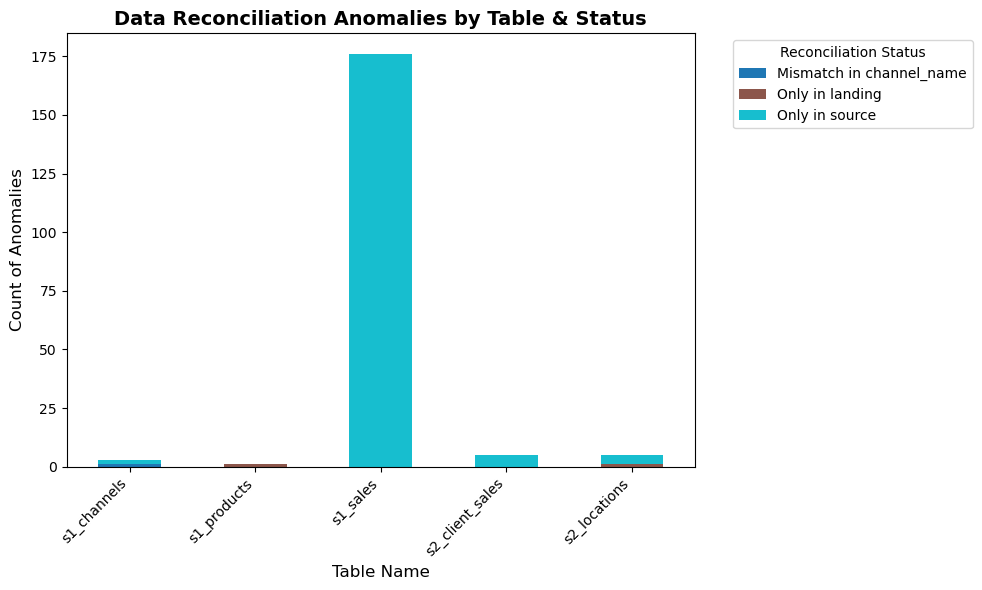

In [63]:
import matplotlib.pyplot as plt

# 1. Stacked Bar Chart for Reconciliation Summary by Table (Much easier to read composition)
summary = final_reconciliation_df.groupby(['table_name', 'reconciliation_status']).size().unstack(fill_value=0)
ax = summary.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab10')

plt.title('Data Reconciliation Anomalies by Table & Status', fontsize=14, fontweight='bold')
plt.xlabel('Table Name', fontsize=12)
plt.ylabel('Count of Anomalies', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Reconciliation Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

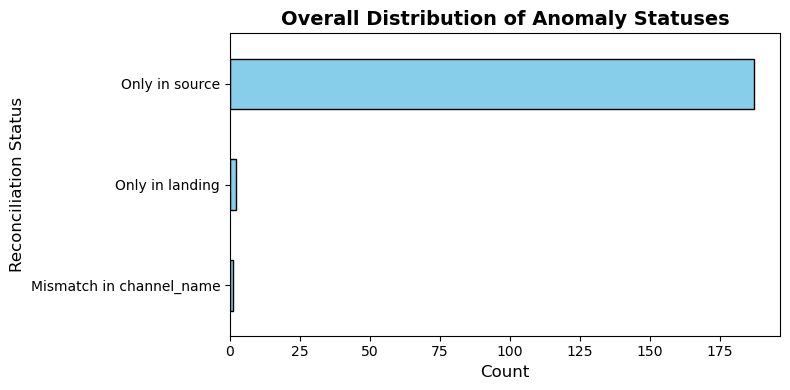

In [67]:
import matplotlib.pyplot as plt

# 2. Horizontal Bar Chart for Overall Status Distribution (Replaces the broken pie chart)
plt.figure(figsize=(8, 4))
status_counts = final_reconciliation_df['reconciliation_status'].value_counts()
status_counts.plot(kind='barh', color='skyblue', edgecolor='black')

plt.title('Overall Distribution of Anomaly Statuses', fontsize=14, fontweight='bold')
plt.xlabel('Count', fontsize=12)
plt.ylabel('Reconciliation Status', fontsize=12)
plt.gca().invert_yaxis()  # Put the largest category on top
plt.tight_layout()
plt.show()

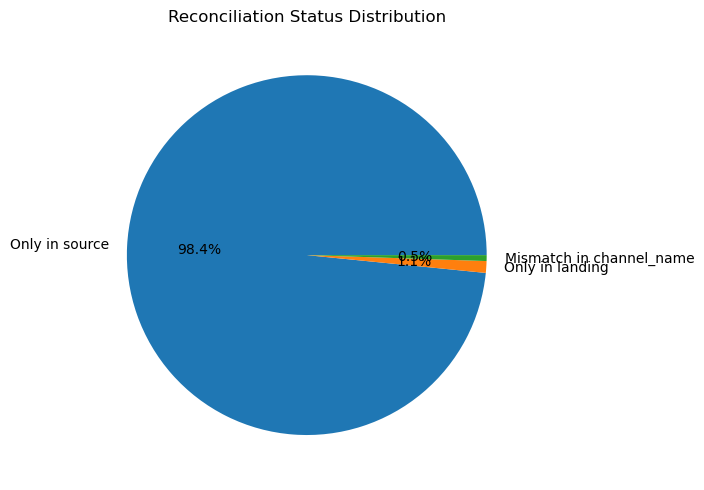

In [69]:
import matplotlib.pyplot as plt

# 3. Overall status distribution (pie chart)
status_counts = final_reconciliation_df['reconciliation_status'].value_counts()
status_counts.plot(kind='pie', autopct='%1.1f%%', title='Reconciliation Status Distribution', figsize=(7,7))
plt.ylabel('')
plt.tight_layout()
plt.show()